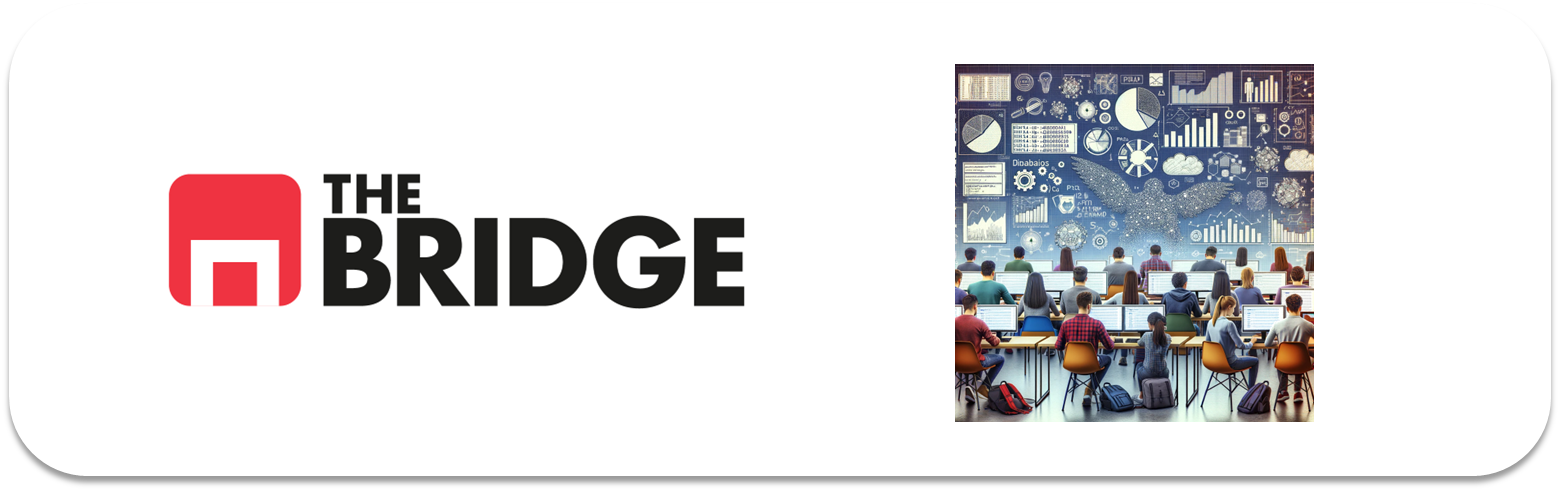

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [2]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep="|")

##### Mini-EDA:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [5]:
train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 44)

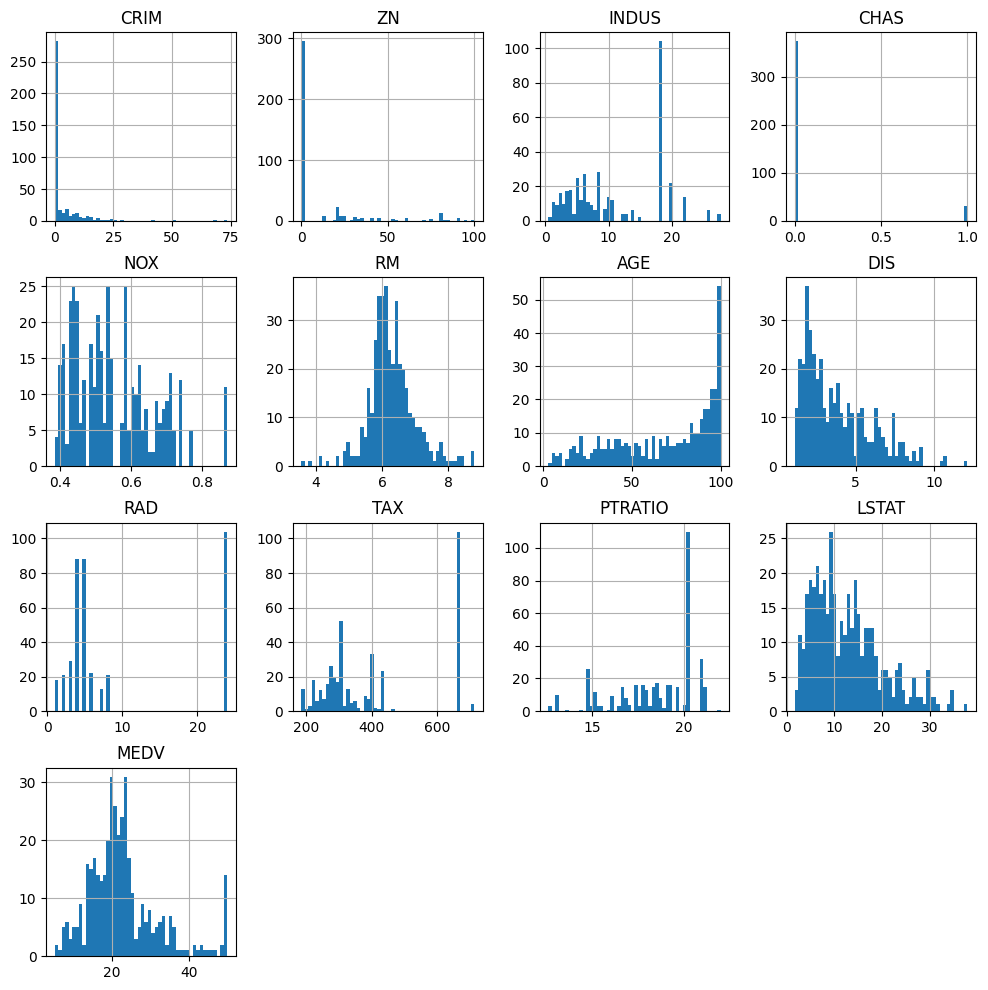

In [6]:
train_set.hist(bins=50, figsize = (12,12))
plt.show()

##### Selección de features:

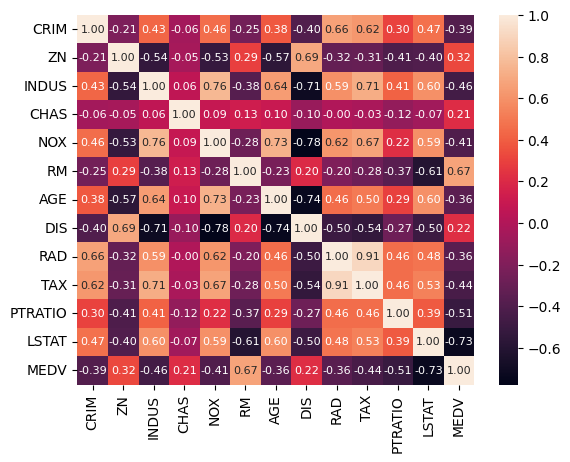

In [7]:
sns.heatmap(train_set.corr(numeric_only = True), annot = True, fmt = ".2f", annot_kws = {"size": 8})
plt.show()

In [8]:
# como features, nos quedamos con las variables que tienen mayor correlación con la variable target (MEDV)
# ya sea negativa o positiva, nos quedamos con los valores absolutos más altos

features = ["CRIM", "INDUS", "NOX", "RM", "AGE", "RAD", "TAX", "PTRATIO", "LSTAT", "ZN"]
target = "MEDV"

Apuntes clase:

```python
criterio = 0.31

feature_num = (
    np.abs(corr[target]) > criterio
)

feature_num = feature_num[
    feature_num
].index.to_list()


In [9]:
X_train = train_set[features]
y_train = train_set[target]

##### Aplicación de escala logaritmica a CRIM y LSTAT debido a la distribución de sus valores, con muchos valores extremos que generan una cola muy larga de valores:

In [10]:
log_cols = ["CRIM", "LSTAT"]

X_train[log_cols] = np.log1p(X_train[log_cols])

##### Estandarización de los valores para centrar los datos en media 0 y desviación típica 1:

In [11]:
std_scaler = StandardScaler()

X_train = pd.DataFrame(
    std_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

##### Entrenamiento del modelo con Linear Regression:

In [12]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### Aplicación del modelo entrenado sobre el train_set para obtener la prediccion:

In [13]:
pred_y_train = lin_reg.predict(X_train)

##### Calculo del peso de cada feature:

In [14]:
peso_features = pd.DataFrame({"Feature": X_train.columns,
                              "Coeficientes": lin_reg.coef_})

peso_features

,Feature,Coeficientes
0,CRIM,-1.762067
1,INDUS,0.712352
2,NOX,-0.660252
3,RM,1.433212
4,AGE,1.842903
5,RAD,3.247903
6,TAX,-1.965223
7,PTRATIO,-2.081392
8,LSTAT,-6.370085
9,ZN,-0.299973


Apuntes clase: 
```python
y_pred = (lin_reg.intercept_) + -1.762 * CRIM + 0.71 * INDUS + ...

##### Aplicamos las mismas trasnformaciones al test_set:

In [15]:
X_test = test_set[features]
y_test = test_set[target]

In [16]:
X_test[log_cols] = np.log1p(X_test[log_cols])

In [17]:
X_test = pd.DataFrame(
    std_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

##### Aplicación del modelo entrenado sobre el test_set para obtener la prediccion:

In [18]:
pred_y_test = lin_reg.predict(X_test)

##### Evaluación del modelo:

Evaluación del modelo sobre train_set empleando la Raíz Cuadrada del Error Cuadratico Medio:

In [19]:
train_rmse = root_mean_squared_error(y_train, pred_y_train)

print(train_rmse)

4.669992380844866


Cross Validation sobre train_set:

In [20]:
cv_lin_rmse = -cross_val_score(lin_reg, X_train, y_train, scoring = "neg_root_mean_squared_error", cv = 10)

cv_lin_rmse_results = pd.Series(cv_lin_rmse).describe()

Evaluación del modelo sobre test_set empleando la Raíz Cuadrada del Error Cuadratico Medio:

In [21]:
test_rmse = root_mean_squared_error(y_test, pred_y_test)

print(test_rmse)

4.016837468385336


In [22]:
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse: .2f}")
print(f"CV RMSE Mean: {cv_lin_rmse.mean():.2f}")
print(f"CV RMSE Std: {cv_lin_rmse_results.loc["std"]:.2f}")

Train RMSE: 4.67
Test RMSE:  4.02
CV RMSE Mean: 4.73
CV RMSE Std: 1.05


Representación gráfica de la comparación entre los valores reales y las predicciones sobre el test_set:

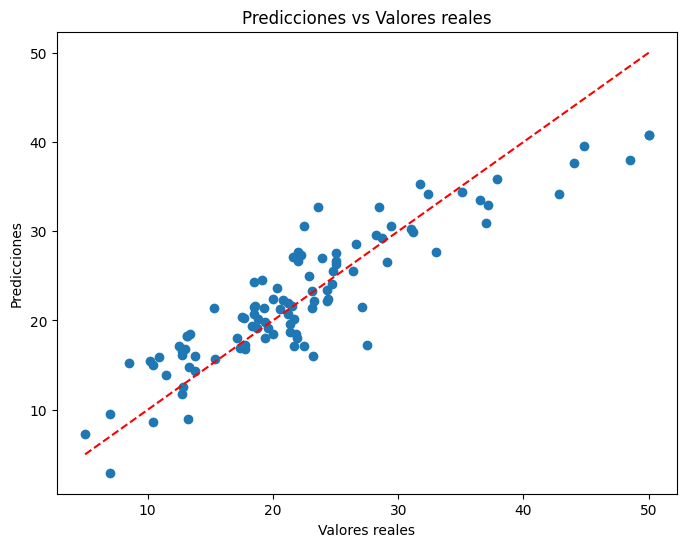

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_y_test)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores reales")

plt.show()

Las predicciones siguen razonablemente la diagonal esperada, lo que indica que el modelo captura correctamente la relación entre las variables y el target. Se observa cierta dispersión y una ligera infraestimación en valores altos, aunque el ajuste general es bueno.

##### Ridge - Modelo alternativo escogido para la regresión normalizada:

Hiperparámetro alpha = 10:

In [24]:
ridgeR = Ridge(alpha = 10)

ridgeR.fit(X_train, y_train)

print("Train RMSE sin regularización:", round(train_rmse, 2))
print("Test RMSE sin regularización:", round(test_rmse,2))

print("Train RMSE con regularización y alpha = 10:", round(root_mean_squared_error(y_train, ridgeR.predict(X_train)), 2))
print("Test RMSE con regularización y alpha = 10:", round(root_mean_squared_error(y_test, ridgeR.predict(X_test)),2))


Train RMSE sin regularización: 4.67
Test RMSE sin regularización: 4.02
Train RMSE con regularización y alpha = 10: 4.69
Test RMSE con regularización y alpha = 10: 4.02


Hiperparámetro alpha = 5:

In [25]:
ridgeR_2 = Ridge(alpha = 5)

ridgeR_2.fit(X_train, y_train)

print("Train RMSE sin regularización:", round(train_rmse, 2))
print("Test RMSE sin regularización:", round(test_rmse,2))

print("Train RMSE con regularización y alpha = 5:", round(root_mean_squared_error(y_train, ridgeR_2.predict(X_train)), 2))
print("Test RMSE con regularización y alpha = 5:", round(root_mean_squared_error(y_test, ridgeR_2.predict(X_test)),2))

Train RMSE sin regularización: 4.67
Test RMSE sin regularización: 4.02
Train RMSE con regularización y alpha = 5: 4.68
Test RMSE con regularización y alpha = 5: 4.01


Hiperparámetro alpha = 1:

In [26]:
ridgeR_3 = Ridge(alpha = 1)

ridgeR_3.fit(X_train, y_train)

print("Train RMSE sin regularización:", round(train_rmse, 2))
print("Test RMSE sin regularización:", round(test_rmse,2))

print("Train RMSE con regularización y alpha = 1:", round(root_mean_squared_error(y_train, ridgeR_3.predict(X_train)), 2))
print("Test RMSE con regularización y alpha = 1:", round(root_mean_squared_error(y_test, ridgeR_3.predict(X_test)),2))

Train RMSE sin regularización: 4.67
Test RMSE sin regularización: 4.02
Train RMSE con regularización y alpha = 1: 4.67
Test RMSE con regularización y alpha = 1: 4.02


##### Conclusiones y elección del modelo:

Tras probar distintos valores de alpha en Ridge, no se observa una mejora significativa ni en el error de train ni en el error de test respecto a Linear Regression. Además, la diferencia entre train y test RMSE ya era reducida, lo que indica que el modelo original no presentaba un overfitting importante. Por ello, se opta por mantener Linear Regression al tratarse de un modelo más simple que ofrece un rendimiento similar.